# Customer Segmentation Using RFM Analysis

## Business Problem
This project helps a retail business identify which customers are most valuable, which customers are at risk of churning, and which customer groups should receive targeted marketing actions.

## Objective
The goal is to segment customers using RFM analysis based on:

- Recency: how recently a customer purchased
- Frequency: how often a customer purchased
- Monetary: how much revenue a customer generated

This analysis supports better retention, upselling, and acquisition strategies.

## RFM Methodology
RFM stands for Recency, Frequency, and Monetary. Using these three metrics, we can rank customers by their recent buying behavior, purchase consistency, and contribution to revenue. The resulting segments help the business prioritize marketing resources and act more strategically.

## Expected Business Value
A good segmentation strategy helps the business answer where revenue is coming from, who is becoming less active, which customers are most loyal, and which customer segments need proactive retention campaigns.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Raw Dataset
The notebook resolves the raw sales file using project-relative paths so it can run from the repository root or the notebook directory. In this project, the raw file is stored under the repository’s dataset folder as well as the expected data/raw folder path in the project brief.

In [5]:
def find_dataset_path():
    candidate_paths = [
        Path.cwd() / "data" / "raw" / "superstore_raw.csv",
        Path.cwd() / "dataset" / "raw" / "SuperStore_Sales_Dataset.csv",
        Path.cwd() / "dataset" / "raw" / "superstore_raw.csv",
        Path.cwd().parent / "data" / "raw" / "superstore_raw.csv",
        Path.cwd().parent / "dataset" / "raw" / "SuperStore_Sales_Dataset.csv",
        Path.cwd().parent / "dataset" / "raw" / "superstore_raw.csv",
    ]
    for path in candidate_paths:
        if path.exists():
            return path
    raise FileNotFoundError("Could not find the raw SuperStore CSV file in the project directories.")

raw_data_path = find_dataset_path()
print(f"Using dataset: {raw_data_path}")
raw_df = pd.read_csv(
    raw_data_path,
    na_values=["", "#N/A", "N/A", "NA", "NULL", "null"],
    keep_default_na=True,
)

# Clean the first column name if the source file contains a formatting artifact.
raw_df.columns = [str(col).strip() for col in raw_df.columns]
if len(raw_df.columns) > 0 and raw_df.columns[0].startswith("Row ID"):
    raw_df = raw_df.rename(columns={raw_df.columns[0]: "Row ID"})

print("\nFirst 5 rows:")
display(raw_df.head())
print("\nLast 5 rows:")
display(raw_df.tail())
print(f"\nShape: {raw_df.shape}")
print("\nColumns:")
print(list(raw_df.columns))
print("\nData types:")
display(raw_df.dtypes)

Using dataset: d:\Data Analyst\Syntecxhub-Data-Analysis-Internship\Syntecxhub_Customer_Segmentation_RFM\dataset\raw\SuperStore_Sales_Dataset.csv

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,01-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.27,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.27,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.27,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,03-01-2019,05-01-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.61,NaN,Online,NaN,NaN
4,8604,US-2019-116365,03-01-2019,08-01-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.26,NaN,Online,NaN,NaN



Last 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
5896,907,CA-2020-143259,30-12-2020,03-01-2021,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",213.14,4,12.12,NaN,COD,NaN,NaN
5897,1297,CA-2020-115427,30-12-2020,03-01-2021,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",295.90,2,4.52,1.00,Online,NaN,NaN
5898,5092,CA-2020-156720,30-12-2020,03-01-2021,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,388.02,3,-0.60,NaN,Online,NaN,NaN
5899,909,CA-2020-143259,30-12-2020,03-01-2021,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,462.78,3,19.79,NaN,COD,NaN,NaN
5900,5093,CA-2020-151450,31-12-2020,04-01-2021,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,"2,975.51",3,-0.60,NaN,COD,NaN,NaN



Shape: (5901, 23)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1', 'ind2']

Data types:


Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Profit           float64
Returns          float64
Payment Mode         str
ind1             float64
ind2             float64
dtype: object

## 2. Data Quality Assessment
Before building the RFM model, it is important to inspect the raw data for duplicates, missing values, invalid dates, and inconsistent values. The goal is to understand the data quality without silently changing the source records.

In [6]:
missing_values = raw_df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print("Missing values by column:")
print(missing_values)

print(f"\nDuplicate rows: {raw_df.duplicated().sum()}")
print(f"Duplicate Order IDs: {raw_df['Order ID'].duplicated().sum() if 'Order ID' in raw_df.columns else 'N/A'}")
print(f"Duplicate Customer IDs: {raw_df['Customer ID'].duplicated().sum() if 'Customer ID' in raw_df.columns else 'N/A'}")

for column in ["Order Date", "Ship Date", "Sales", "Quantity", "Profit", "Returns"]:
    if column in raw_df.columns:
        print(f"\n--- {column} ---")
        print(raw_df[column].head())

print("\nUnique counts by column:")
for column in raw_df.columns:
    print(f"{column}: {raw_df[column].nunique(dropna=True)}")

# Date validation
if "Order Date" in raw_df.columns:
    order_dates = pd.to_datetime(raw_df["Order Date"], errors="coerce", dayfirst=True)
    print(f"\nInvalid Order Date values: {order_dates.isna().sum()}")
if "Ship Date" in raw_df.columns:
    ship_dates = pd.to_datetime(raw_df["Ship Date"], errors="coerce", dayfirst=True)
    print(f"Invalid Ship Date values: {ship_dates.isna().sum()}")

# Numerical validation
numeric_checks = {
    "Sales <= 0": float((pd.to_numeric(raw_df["Sales"], errors="coerce") <= 0).sum()) if "Sales" in raw_df.columns else np.nan,
    "Quantity <= 0": float((pd.to_numeric(raw_df["Quantity"], errors="coerce") <= 0).sum()) if "Quantity" in raw_df.columns else np.nan,
    "Profit <= 0": float((pd.to_numeric(raw_df["Profit"], errors="coerce") <= 0).sum()) if "Profit" in raw_df.columns else np.nan,
}
print("\nNumerical validity checks:")
for key, value in numeric_checks.items():
    print(f"{key}: {value}")

if "Returns" in raw_df.columns:
    returns_values = raw_df["Returns"].astype(str).str.upper().str.strip()
    bad_returns = returns_values[returns_values.isin(["#N/A", "N/A", "NA", "NONE", "NULL", "", "nan"])].count()
    print(f"\nInvalid or missing Returns values: {bad_returns}")

# Check categorical consistency
categorical_columns = ["Segment", "Country", "City", "State", "Region", "Category", "Sub-Category", "Ship Mode", "Payment Mode"]
for column in categorical_columns:
    if column in raw_df.columns:
        unique_values = sorted(raw_df[column].dropna().astype(str).unique())[:10]
        print(f"\n{column} sample values: {unique_values}")

print("\nData quality assessment complete.")

Missing values by column:
ind2       5901
ind1       5901
Returns    5614
dtype: int64

Duplicate rows: 0
Duplicate Order IDs: 2898
Duplicate Customer IDs: 5128

--- Order Date ---
0    01-01-2019
1    02-01-2019
2    02-01-2019
3    03-01-2019
4    03-01-2019
Name: Order Date, dtype: str

--- Ship Date ---
0    07-01-2019
1    07-01-2019
2    07-01-2019
3    05-01-2019
4    08-01-2019
Name: Ship Date, dtype: str

--- Sales ---
0    73.94
1   173.94
2   231.98
3   114.46
4    30.08
Name: Sales, dtype: float64

--- Quantity ---
0    1
1    3
2    2
3    2
4    2
Name: Quantity, dtype: int64

--- Profit ---
0   28.27
1   38.27
2   67.27
3   28.61
4   -5.26
Name: Profit, dtype: float64

--- Returns ---
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Returns, dtype: float64

Unique counts by column:
Row ID: 5900
Order ID: 3003
Order Date: 643
Ship Date: 690
Ship Mode: 4
Customer ID: 773
Customer Name: 773
Segment: 3
Country: 1
City: 452
State: 49
Region: 4
Product ID: 1755
Category: 3
Sub-Ca

## 3. Data Cleaning and Preparation
The cleaning step creates a working dataset without overwriting the raw file. Important cleaning decisions are documented here:

- Convert date columns to datetime so recency is calculated correctly.
- Convert numeric fields such as Sales, Quantity, and Profit to numeric values.
- Treat placeholder values such as #N/A as missing values rather than valid text.
- Remove exact duplicates where the transaction rows are truly identical.
- Keep valid negative profit rows because they can represent legitimate losses or discount-driven sales; they are not automatically invalid.
- Retain rows with realistic business values while excluding impossible records that lack essential transaction identifiers.

In [7]:
working_df = raw_df.copy()

# Remove exact duplicate rows
before_dedup = working_df.shape[0]
working_df = working_df.drop_duplicates().copy()
print(f"Rows removed by duplicate detection: {before_dedup - working_df.shape[0]}")

# Standardize column names and missing markers
working_df.columns = [str(col).strip().replace("+O6G3A1:R6", "") for col in working_df.columns]

for column in ["Order Date", "Ship Date"]:
    if column in working_df.columns:
        working_df[column] = pd.to_datetime(working_df[column], errors="coerce", dayfirst=True)

for column in ["Sales", "Quantity", "Profit"]:
    if column in working_df.columns:
        working_df[column] = pd.to_numeric(working_df[column], errors="coerce")

if "Returns" in working_df.columns:
    working_df["Returns"] = working_df["Returns"].replace(["#N/A", "N/A", "NA", "NULL", "null", ""], np.nan)
    working_df["Returns"] = pd.to_numeric(working_df["Returns"], errors="coerce")

# Standardize text columns to avoid subtle string inconsistencies
for column in ["Customer ID", "Customer Name", "Segment", "Country", "State", "Region", "Category", "Sub-Category", "Payment Mode"]:
    if column in working_df.columns:
        working_df[column] = working_df[column].astype(str).str.strip()
        working_df[column] = working_df[column].replace("nan", np.nan)

# Keep only rows with a valid order date, customer ID, and sales value for RFM analysis
essential_fields = ["Order Date", "Customer ID", "Sales"]
valid_mask = pd.Series(True, index=working_df.index)
for field in essential_fields:
    if field in working_df.columns:
        valid_mask &= working_df[field].notna()
working_df = working_df.loc[valid_mask].copy()

print(f"\nCleaned dataset shape: {working_df.shape}")
print("\nRemaining missing values:")
print(working_df.isnull().sum().sort_values(ascending=False)[lambda s: s > 0])
print("\nData types after cleaning:")
display(working_df.dtypes)
print("\nDescriptive statistics for numeric fields:")
display(working_df.describe(include=[np.number]))

# Date range check
if "Order Date" in working_df.columns:
    print(f"\nOrder date min: {working_df['Order Date'].min()}")
    print(f"Order date max: {working_df['Order Date'].max()}")

Rows removed by duplicate detection: 0

Cleaned dataset shape: (5901, 23)

Remaining missing values:
ind2       5901
ind1       5901
Returns    5614
dtype: int64

Data types after cleaning:


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Profit                  float64
Returns                 float64
Payment Mode                str
ind1                    float64
ind2                    float64
dtype: object


Descriptive statistics for numeric fields:


,Row ID,Sales,Quantity,Profit,Returns,ind1,ind2
count,"5,901.00","5,901.00","5,901.00","5,901.00",287.00,0.00,0.00
mean,"5,022.42",265.35,3.78,29.70,1.00,NaN,NaN
std,"2,877.98",474.26,2.21,259.59,0.00,NaN,NaN
min,1.00,0.84,1.00,"-6,599.98",1.00,NaN,NaN
25%,"2,486.00",71.98,2.00,1.80,1.00,NaN,NaN
50%,"5,091.00",128.65,3.00,8.50,1.00,NaN,NaN
75%,"7,456.00",265.17,5.00,28.61,1.00,NaN,NaN
max,"9,994.00","9,099.93",14.00,"8,399.98",1.00,NaN,NaN



Order date min: 2019-01-01 00:00:00
Order date max: 2020-12-31 00:00:00


In [9]:
# Save the cleaned dataset to the processed folder
from pathlib import Path
processed_data_path = Path.cwd().parent / "dataset" / "processed" / "cleaned_data.csv"
processed_data_path.parent.mkdir(parents=True, exist_ok=True)
working_df.to_csv(processed_data_path, index=False)
print(f"Cleaned dataset saved to: {processed_data_path}")
print(f"Shape: {working_df.shape}")
print(f"File size: {processed_data_path.stat().st_size / 1024 / 1024:.2f} MB")

Cleaned dataset saved to: d:\Data Analyst\Syntecxhub-Data-Analysis-Internship\Syntecxhub_Customer_Segmentation_RFM\dataset\processed\cleaned_data.csv
Shape: (5901, 23)
File size: 1.30 MB


## 4. Exploratory Data Analysis (EDA)
This section profiles the business before calculating RFM to understand sales, customer count, profitability, and category performance.

Total sales: $1,565,804.32
Average sales per order: $265.35


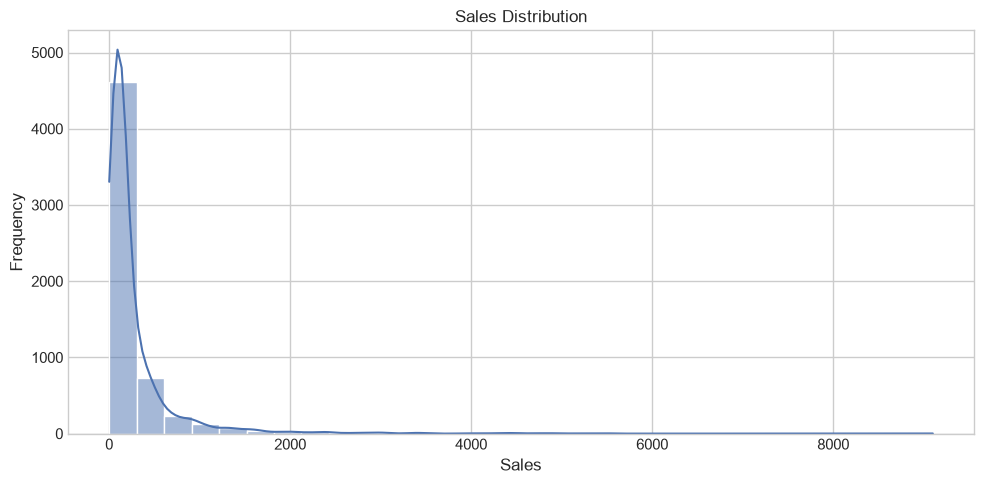

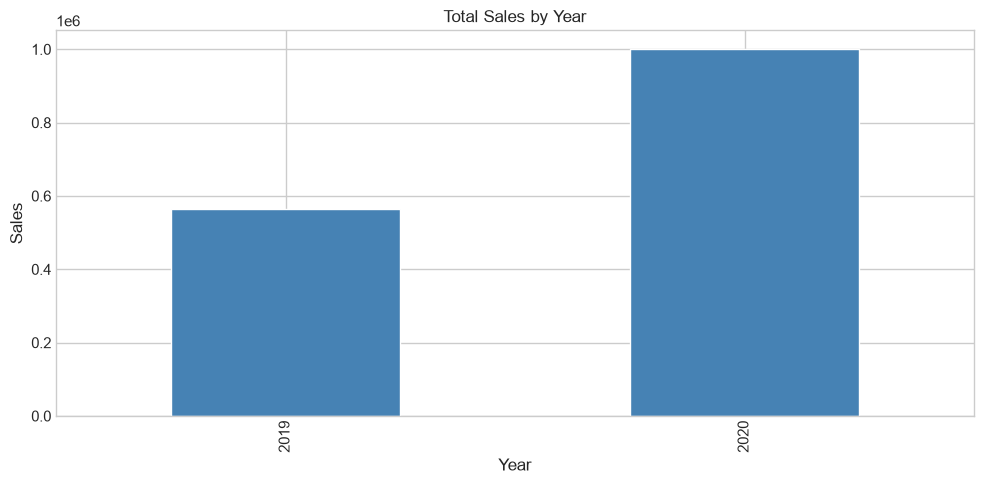

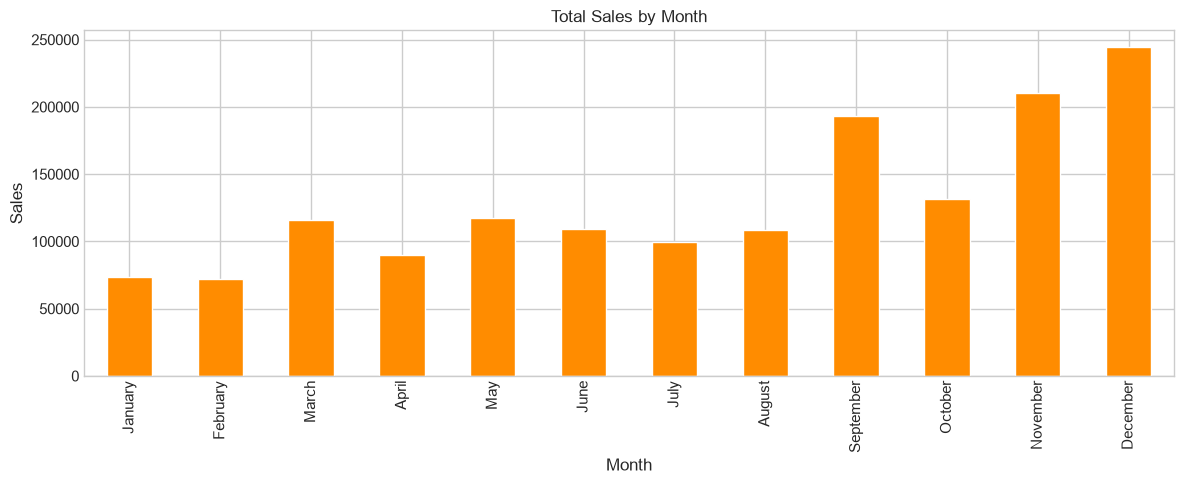

Unique customers: 773
Unique orders: 3003
Average orders per customer: 3.88

Top customers by sales:


,Customer ID,Total_Sales,Customer_Name
144,CJ-12010,"11,596.97",Caroline Jumper
416,KF-16285,"10,941.27",Karen Ferguson
701,SV-20365,"10,751.15",Seth Vernon
325,HW-14935,"10,074.93",Helen Wasserman
252,EH-13765,"9,542.99",Edward Hooks
103,BS-11365,"9,199.78",Bill Shonely
581,PK-19075,"8,812.05",Pete Kriz
376,JL-15835,"8,765.33",John Lee
5,AB-10060,"8,167.08",Adam Bellavance
399,JW-15220,"7,933.55",Jane Waco



Total profit: $175,262.11
Average profit: $29.70


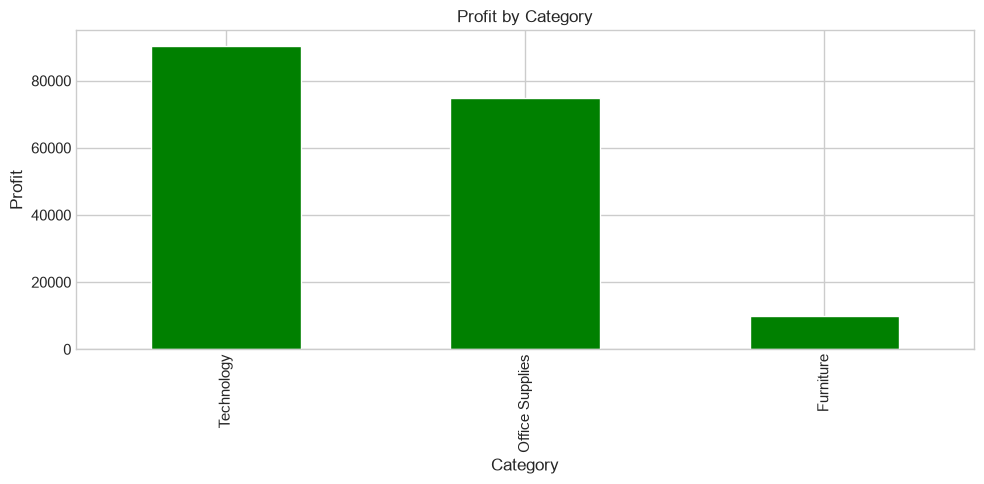

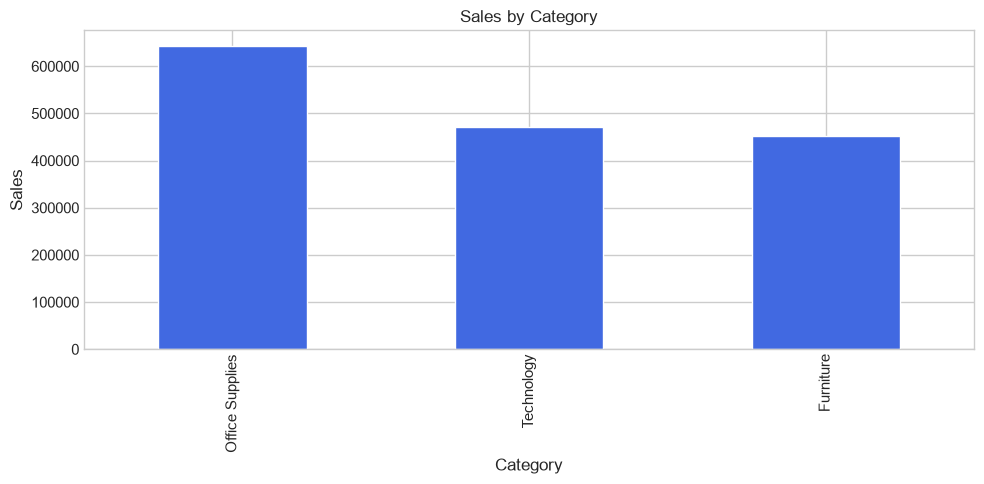

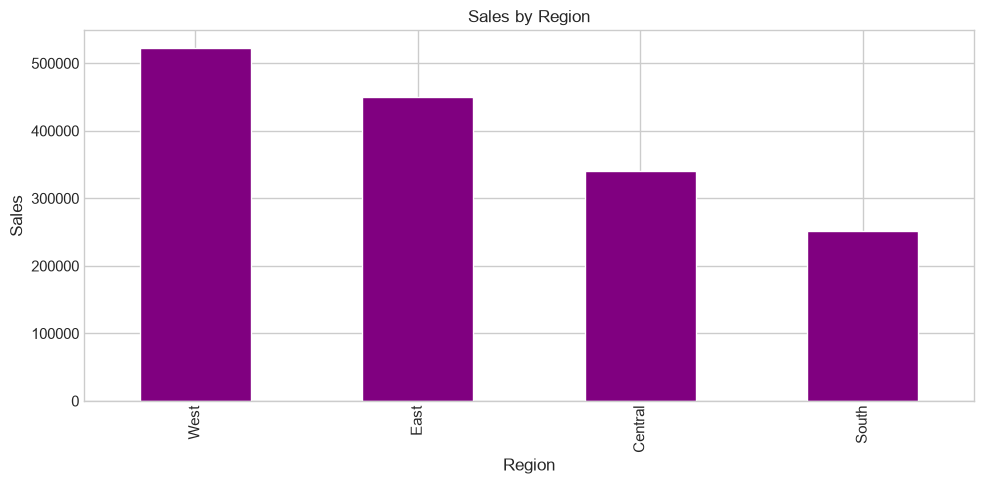

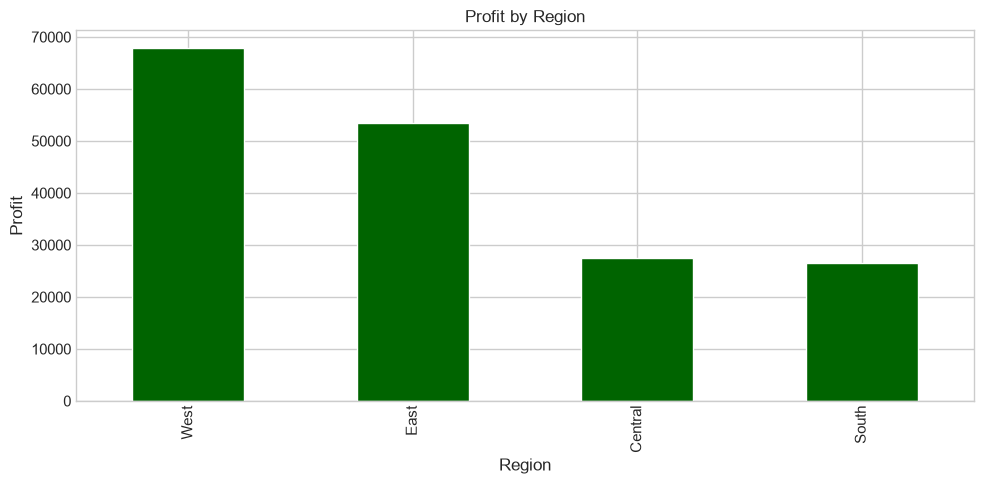

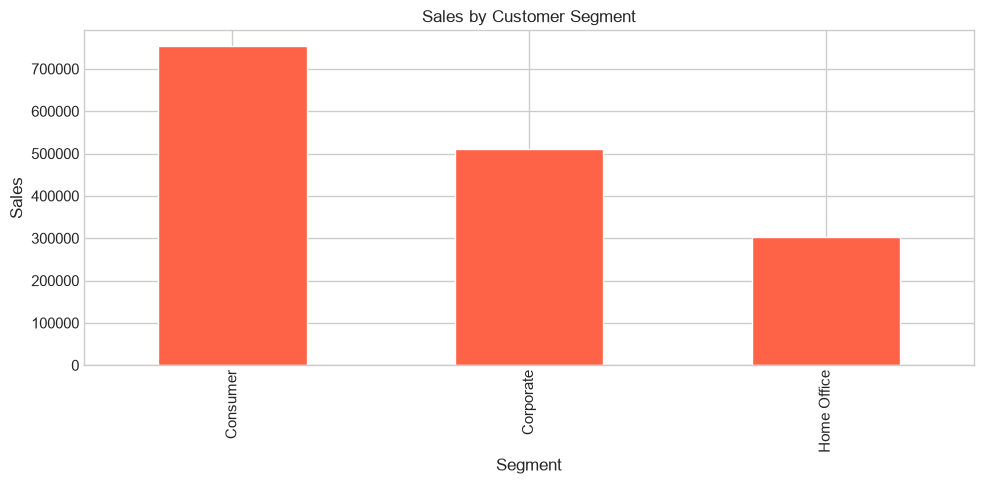

In [5]:
# Sales overview
sales_total = working_df["Sales"].sum()
average_sales = working_df["Sales"].mean()
print(f"Total sales: ${sales_total:,.2f}")
print(f"Average sales per order: ${average_sales:,.2f}")

# Distribution of sales
plt.figure(figsize=(10, 5))
sns.histplot(working_df["Sales"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Sales by year and month
working_df["Order Year"] = working_df["Order Date"].dt.year
working_df["Order Month"] = working_df["Order Date"].dt.month_name()

sales_by_year = working_df.groupby("Order Year")["Sales"].sum().sort_index()
plt.figure(figsize=(10, 5))
sales_by_year.plot(kind="bar", color="steelblue")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

sales_by_month = working_df.groupby("Order Month")["Sales"].sum().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])
plt.figure(figsize=(12, 5))
sales_by_month.plot(kind="bar", color="darkorange")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# Customer overview
customer_count = working_df["Customer ID"].nunique()
order_count = working_df["Order ID"].nunique()
orders_per_customer = order_count / customer_count if customer_count else 0
print(f"Unique customers: {customer_count}")
print(f"Unique orders: {order_count}")
print(f"Average orders per customer: {orders_per_customer:,.2f}")

customer_sales = (
    working_df.groupby("Customer ID", as_index=False)
    .agg(Total_Sales=("Sales", "sum"), Customer_Name=("Customer Name", "first"))
    .sort_values("Total_Sales", ascending=False)
)
print("\nTop customers by sales:")
display(customer_sales.head(10))

# Profit and category analysis
profit_total = working_df["Profit"].sum()
profit_average = working_df["Profit"].mean()
print(f"\nTotal profit: ${profit_total:,.2f}")
print(f"Average profit: ${profit_average:,.2f}")

profit_by_category = working_df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
profit_by_category.plot(kind="bar", color="green")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

sales_by_category = working_df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sales_by_category.plot(kind="bar", color="royalblue")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

sales_by_region = working_df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
profit_by_region = working_df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sales_by_region.plot(kind="bar", color="purple")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
profit_by_region.plot(kind="bar", color="darkgreen")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

sales_by_segment = working_df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sales_by_segment.plot(kind="bar", color="tomato")
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## 5. Define Review Date for RFM
For recency, the analysis date should be anchored to the dataset itself. Using the maximum order date plus one day prevents the most recent purchase from being treated as zero days old and keeps recency logic consistent for a live reporting process.

In [6]:
analysis_date = working_df["Order Date"].max() + pd.Timedelta(days=1)
print(f"Analysis date: {analysis_date}")

Analysis date: 2021-01-01 00:00:00


## 6. Calculate RFM Metrics
The RFM dataset is built at the customer level using unique order IDs, not a raw row count, because one order can have multiple products or product lines.

In [7]:
customer_rfm = (
    working_df.groupby("Customer ID", as_index=False)
    .agg(
        Customer_Name=("Customer Name", "first"),
        Segment=("Segment", "first"),
        Region=("Region", "first"),
        Recency=("Order Date", lambda x: (analysis_date - x.max()).days),
        Frequency=("Order ID", "nunique"),
        Monetary=("Sales", "sum"),
    )
    .sort_values("Monetary", ascending=False)
    .reset_index(drop=True)
)

print("RFM dataset preview:")
display(customer_rfm.head(10))

RFM dataset preview:


,Customer ID,Customer_Name,Segment,Region,Recency,Frequency,Monetary
0,CJ-12010,Caroline Jumper,Consumer,East,191,8,"11,596.97"
1,KF-16285,Karen Ferguson,Home Office,West,99,6,"10,941.27"
2,SV-20365,Seth Vernon,Consumer,West,103,7,"10,751.15"
3,HW-14935,Helen Wasserman,Corporate,East,119,7,"10,074.93"
4,EH-13765,Edward Hooks,Corporate,West,137,9,"9,542.99"
5,BS-11365,Bill Shonely,Corporate,East,561,2,"9,199.78"
6,PK-19075,Pete Kriz,Consumer,South,11,11,"8,812.05"
7,JL-15835,John Lee,Consumer,East,23,7,"8,765.33"
8,AB-10060,Adam Bellavance,Home Office,South,56,7,"8,167.08"
9,JW-15220,Jane Waco,Corporate,West,44,5,"7,933.55"


## 7. RFM Distribution Analysis
The RFM scores are based on distributions that often skew to the right because a small number of customers account for a large share of revenue and purchases. This is common in transaction data and is important when setting thresholds and interpreting segments.

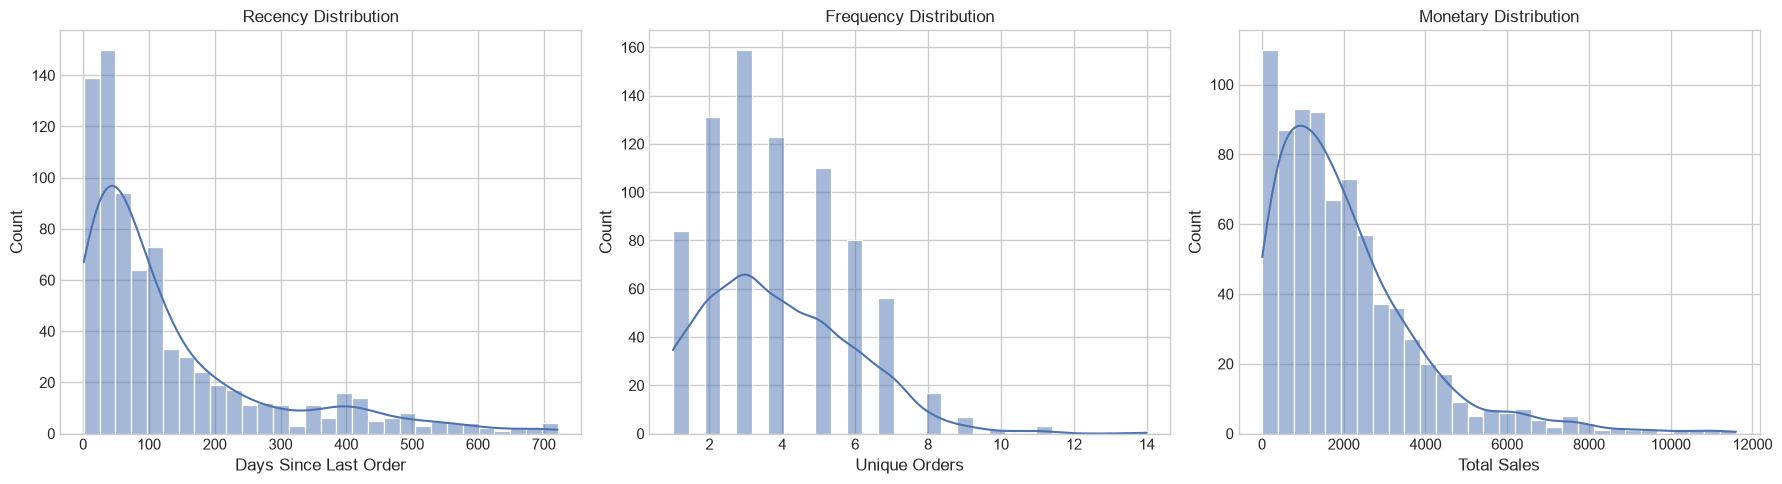


Recency summary:
count   773.00
mean    130.39
std     146.75
min       1.00
25%      31.00
50%      74.00
75%     164.00
max     721.00
Name: Recency, dtype: float64

Frequency summary:
count   773.00
mean      3.88
std       2.01
min       1.00
25%       2.00
50%       4.00
75%       5.00
max      14.00
Name: Frequency, dtype: float64

Monetary summary:
count      773.00
mean     2,025.62
std      1,778.10
min          5.30
25%        748.74
50%      1,584.78
75%      2,717.49
max     11,596.97
Name: Monetary, dtype: float64


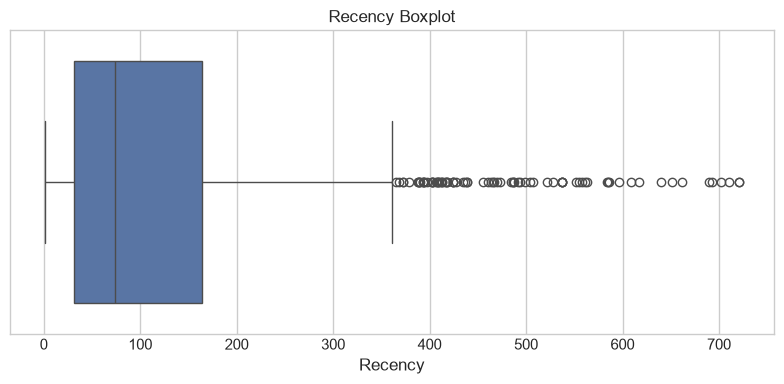

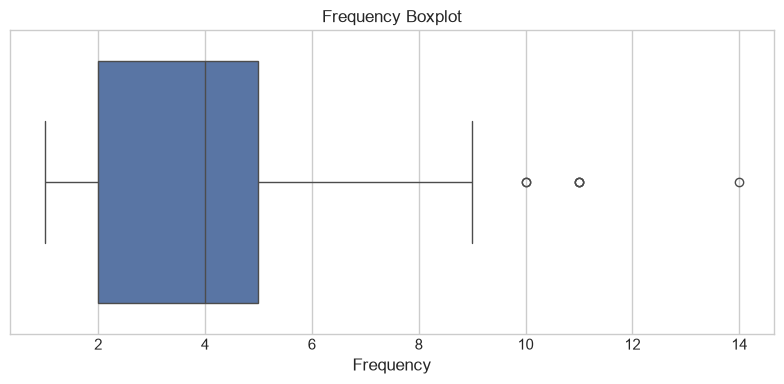

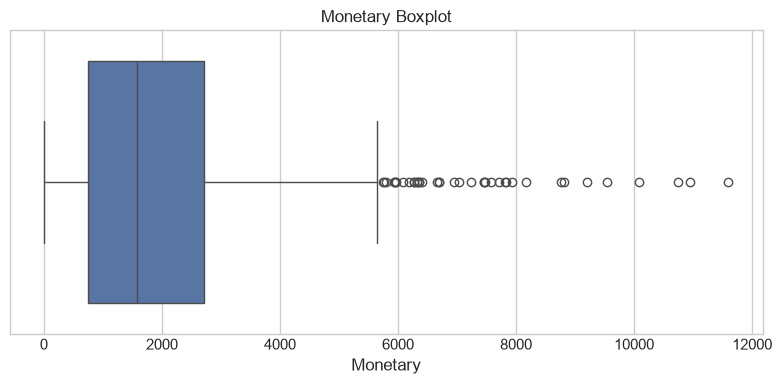

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(customer_rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Order")

sns.histplot(customer_rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Unique Orders")

sns.histplot(customer_rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Sales")

plt.tight_layout()
plt.show()

for column in ["Recency", "Frequency", "Monetary"]:
    print(f"\n{column} summary:")
    print(customer_rfm[column].describe())

for column in ["Recency", "Frequency", "Monetary"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=customer_rfm[column])
    plt.title(f"{column} Boxplot")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

## 8. RFM Scoring
We use a 1–5 scale for each metric, with higher values representing better performance. Recency is reversed because a customer who purchased most recently is more valuable than one who has been inactive longer.

In [9]:
def score_rfm_metric(series, higher_is_better=True):
    ranked = series.rank(method="first", ascending=higher_is_better)
    try:
        bins = pd.qcut(ranked, q=5, labels=False, duplicates="drop")
    except ValueError:
        bins = pd.qcut(ranked, q=min(5, ranked.nunique()), labels=False, duplicates="drop")
    bins = pd.Series(bins, index=series.index).fillna(0).astype(int)
    if higher_is_better:
        return bins + 1
    return 5 - bins

customer_rfm["R_Score"] = score_rfm_metric(customer_rfm["Recency"], higher_is_better=False)
customer_rfm["F_Score"] = score_rfm_metric(customer_rfm["Frequency"], higher_is_better=True)
customer_rfm["M_Score"] = score_rfm_metric(customer_rfm["Monetary"], higher_is_better=True)

customer_rfm["RFM_Score"] = (
    customer_rfm["R_Score"].astype(str)
    + customer_rfm["F_Score"].astype(str)
    + customer_rfm["M_Score"].astype(str)
)
customer_rfm["RFM_Score_Total"] = customer_rfm["R_Score"] + customer_rfm["F_Score"] + customer_rfm["M_Score"]

print("RFM score preview:")
display(customer_rfm[["Customer ID", "Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score", "RFM_Score_Total"]].head(10))

RFM score preview:


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score_Total
0,CJ-12010,191,8,"11,596.97",4,5,5,14
1,KF-16285,99,6,"10,941.27",3,4,5,12
2,SV-20365,103,7,"10,751.15",4,5,5,14
3,HW-14935,119,7,"10,074.93",4,5,5,14
4,EH-13765,137,9,"9,542.99",4,5,5,14
5,BS-11365,561,2,"9,199.78",5,1,5,11
6,PK-19075,11,11,"8,812.05",1,5,5,11
7,JL-15835,23,7,"8,765.33",1,5,5,11
8,AB-10060,56,7,"8,167.08",3,5,5,13
9,JW-15220,44,5,"7,933.55",2,4,5,11


## 9. Customer Segmentation
The segmentation rules below are transparent and based on RFM score patterns rather than arbitrary thresholds. The segments represent explainable customer behavior.

- Champions / Loyal Customers: very high recency, frequency, and monetary value
- Potential Loyal Customers: strong loyalty potential but not yet at champion level
- New Customers: recently active but low frequency
- At Risk Customers: previously active and valuable, but now infrequent or inactive
- Lost / Hibernating Customers: low recency, low frequency, low monetary value
- Other Customers: remaining behavior patterns not captured above

In [10]:
def assign_segment(row):
    if (row["R_Score"] >= 4) and (row["F_Score"] >= 4) and (row["M_Score"] >= 4):
        return "Champions / Loyal Customers"
    elif (row["R_Score"] >= 3) and (row["F_Score"] >= 3) and (row["M_Score"] >= 3):
        return "Potential Loyal Customers"
    elif (row["R_Score"] >= 4) and (row["F_Score"] <= 2):
        return "New Customers"
    elif (row["R_Score"] <= 2) and (row["F_Score"] >= 3) and (row["M_Score"] >= 3):
        return "At Risk Customers"
    elif (row["R_Score"] <= 2) and (row["F_Score"] <= 2):
        return "Lost / Hibernating Customers"
    return "Other Customers"

customer_rfm["Customer_Segment"] = customer_rfm.apply(assign_segment, axis=1)

segment_counts = (
    customer_rfm["Customer_Segment"]
    .value_counts()
    .rename_axis("Customer_Segment")
    .reset_index(name="Customer_Count")
)
segment_counts["Pct_of_Customers"] = segment_counts["Customer_Count"] / segment_counts["Customer_Count"].sum() * 100
print("Customer segments:")
display(segment_counts.sort_values("Customer_Count", ascending=False))

Customer segments:


,Customer_Segment,Customer_Count,Pct_of_Customers
0,Other Customers,193,24.97
1,At Risk Customers,192,24.84
2,New Customers,177,22.90
3,Potential Loyal Customers,107,13.84
4,Lost / Hibernating Customers,74,9.57
5,Champions / Loyal Customers,30,3.88


## 10. Segment Analysis
This section aggregates customer behavior by segment to identify which groups are largest, highest revenue contributors, and most at risk.

In [11]:
customer_level_sales = (
    working_df.groupby("Customer ID", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
    )
)

rfm_segment_analysis = customer_rfm.merge(customer_level_sales, on="Customer ID", how="left")
segment_summary = (
    rfm_segment_analysis.groupby("Customer_Segment", as_index=False)
    .agg(
        Number_of_Customers=("Customer ID", "count"),
        Total_Sales=("Total_Sales", "sum"),
        Average_Sales_Per_Customer=("Total_Sales", "mean"),
        Total_Profit=("Total_Profit", "sum"),
        Average_Recency=("Recency", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Monetary=("Monetary", "mean"),
    )
)
segment_summary["Pct_of_Customers"] = segment_summary["Number_of_Customers"] / segment_summary["Number_of_Customers"].sum() * 100
segment_summary = segment_summary.sort_values(["Number_of_Customers", "Total_Sales"], ascending=[False, False]).reset_index(drop=True)
print("Segment summary:")
display(segment_summary)

largest_segment = segment_summary.sort_values("Number_of_Customers", ascending=False).iloc[0]
highest_revenue_segment = segment_summary.sort_values("Total_Sales", ascending=False).iloc[0]
highest_profit_segment = segment_summary.sort_values("Total_Profit", ascending=False).iloc[0]
highest_value_customers = customer_rfm.sort_values("Monetary", ascending=False).head(5)

print(f"\nLargest segment: {largest_segment['Customer_Segment']} ({largest_segment['Number_of_Customers']} customers)")
print(f"Highest revenue segment: {highest_revenue_segment['Customer_Segment']} (${highest_revenue_segment['Total_Sales']:,.2f})")
print(f"Highest profit segment: {highest_profit_segment['Customer_Segment']} (${highest_profit_segment['Total_Profit']:,.2f})")
print("\nHighest value customers:")
display(highest_value_customers[["Customer ID", "Customer_Name", "Segment", "Region", "Monetary", "Frequency", "Recency"]].head())

at_risk_customers = customer_rfm[customer_rfm["Customer_Segment"] == "At Risk Customers"]
print(f"\nAt-risk customer count: {len(at_risk_customers)}")
print(f"At-risk customer share: {len(at_risk_customers) / len(customer_rfm) * 100:.2f}%")

Segment summary:


,Customer_Segment,Number_of_Customers,Total_Sales,Average_Sales_Per_Customer,Total_Profit,Average_Recency,Average_Frequency,Average_Monetary,Pct_of_Customers
0,Other Customers,193,"175,258.77",908.08,"15,503.65",103.77,3.33,908.08,24.97
1,At Risk Customers,192,"620,568.43","3,232.13","64,902.85",25.42,5.84,"3,232.13",24.84
2,New Customers,177,"200,507.93","1,132.81","34,862.51",317.65,1.94,"1,132.81",22.90
3,Potential Loyal Customers,107,"308,349.28","2,881.77","26,112.44",115.23,5.09,"2,881.77",13.84
4,Lost / Hibernating Customers,74,"127,608.61","1,724.44","14,587.49",26.69,2.23,"1,724.44",9.57
5,Champions / Loyal Customers,30,"133,511.29","4,450.38","19,293.16",178.53,6.13,"4,450.38",3.88



Largest segment: Other Customers (193 customers)
Highest revenue segment: At Risk Customers ($620,568.43)
Highest profit segment: At Risk Customers ($64,902.85)

Highest value customers:


,Customer ID,Customer_Name,Segment,Region,Monetary,Frequency,Recency
0,CJ-12010,Caroline Jumper,Consumer,East,"11,596.97",8,191
1,KF-16285,Karen Ferguson,Home Office,West,"10,941.27",6,99
2,SV-20365,Seth Vernon,Consumer,West,"10,751.15",7,103
3,HW-14935,Helen Wasserman,Corporate,East,"10,074.93",7,119
4,EH-13765,Edward Hooks,Corporate,West,"9,542.99",9,137



At-risk customer count: 192
At-risk customer share: 24.84%


## 11. Segment Visualizations
These charts make the customer segments understandable to business stakeholders and support action-oriented discussion.

C:\Users\Zain Latif\AppData\Local\Temp\ipykernel_11848\1699734903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x="Customer_Segment", y="Number_of_Customers", palette="viridis")


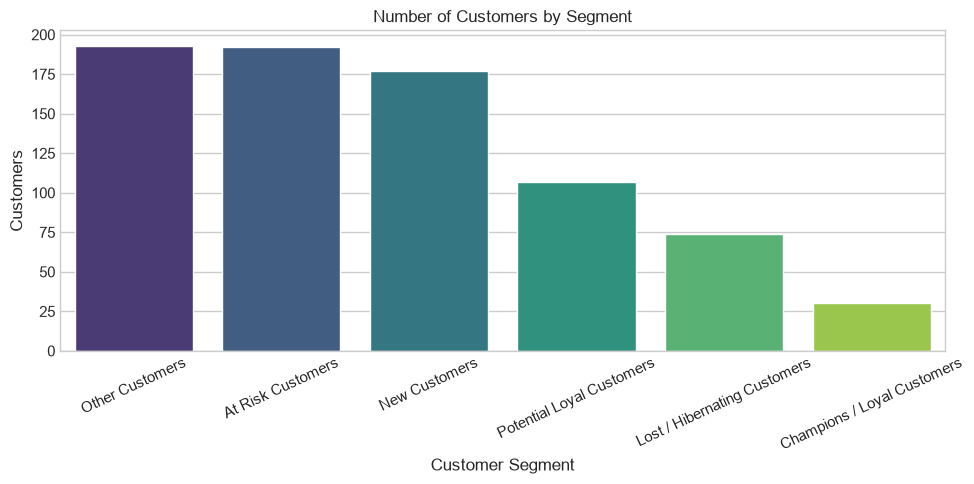

<Figure size 1000x500 with 0 Axes>

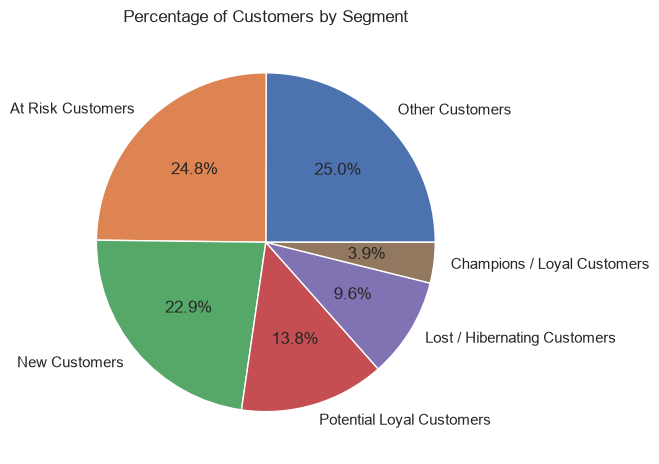

C:\Users\Zain Latif\AppData\Local\Temp\ipykernel_11848\1699734903.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=segment_summary, x="Customer_Segment", y="Total_Sales", palette="Blues_d")


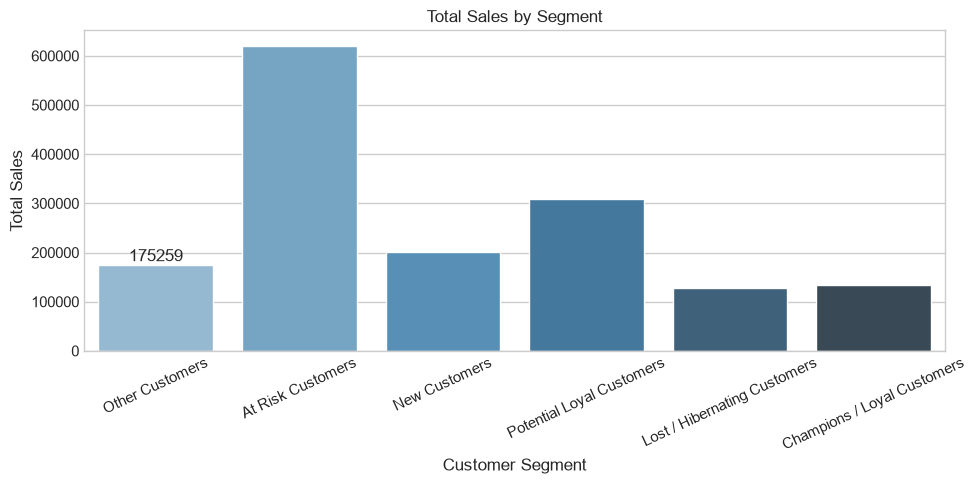

C:\Users\Zain Latif\AppData\Local\Temp\ipykernel_11848\1699734903.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=segment_summary, x="Customer_Segment", y="Total_Profit", palette="Greens_d")


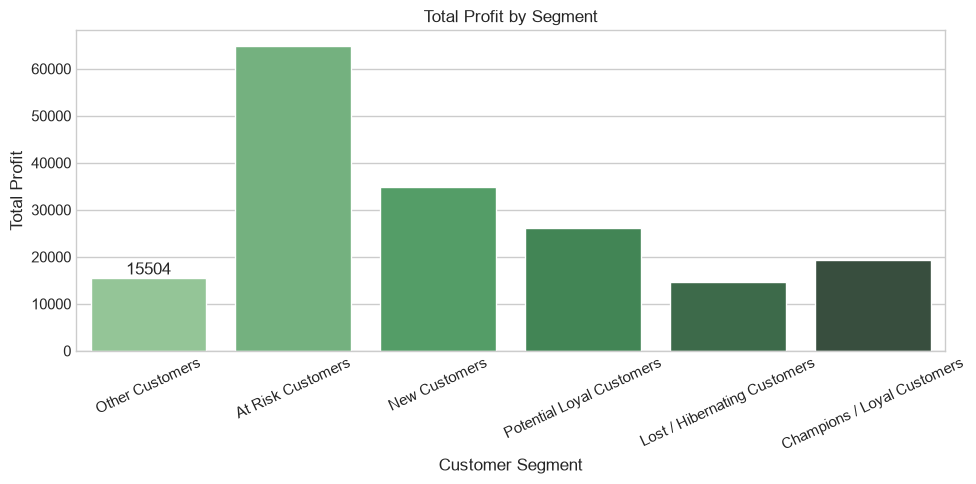

C:\Users\Zain Latif\AppData\Local\Temp\ipykernel_11848\1699734903.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x="Customer_Segment", y="Average_Sales_Per_Customer", palette="rocket")


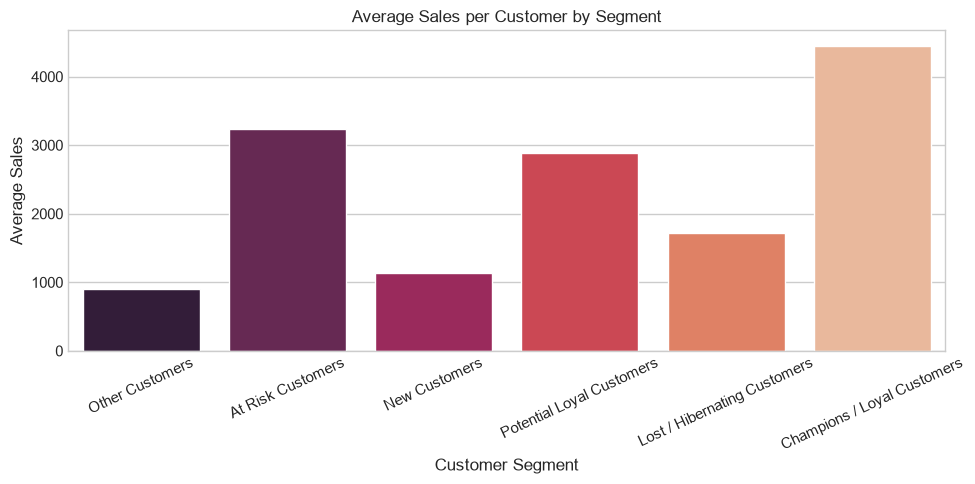

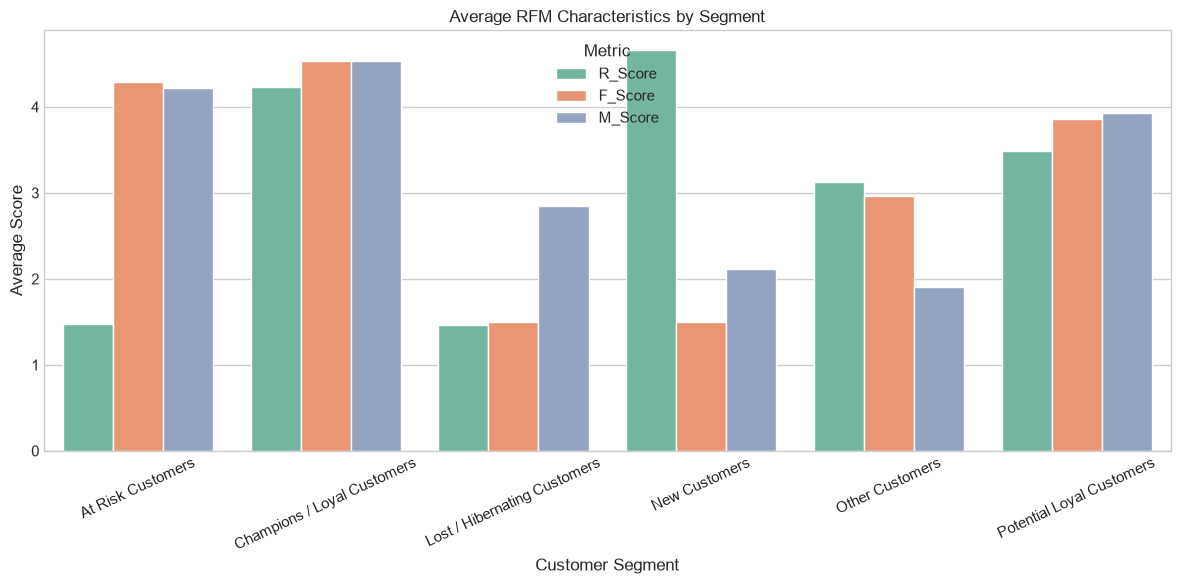

In [12]:
# 1. Number of customers by segment
plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary, x="Customer_Segment", y="Number_of_Customers", palette="viridis")
plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Customers")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 2. Percentage of customers by segment
plt.figure(figsize=(10, 5))
segment_summary.plot(kind="pie", y="Pct_of_Customers", labels=segment_summary["Customer_Segment"], autopct="%1.1f%%", legend=False)
plt.title("Percentage of Customers by Segment")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 3. Revenue by segment
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=segment_summary, x="Customer_Segment", y="Total_Sales", palette="Blues_d")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Total Sales by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 4. Profit by segment
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=segment_summary, x="Customer_Segment", y="Total_Profit", palette="Greens_d")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Total Profit by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 5. Average Monetary by Segment
plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary, x="Customer_Segment", y="Average_Sales_Per_Customer", palette="rocket")
plt.title("Average Sales per Customer by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. RFM characteristics by segment
segment_rfm_profile = (
    customer_rfm.groupby("Customer_Segment")[["R_Score", "F_Score", "M_Score"]].mean().reset_index()
)
segment_rfm_profile = segment_rfm_profile.melt(id_vars="Customer_Segment", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=segment_rfm_profile, x="Customer_Segment", y="Score", hue="Metric", palette="Set2")
plt.title("Average RFM Characteristics by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 12. Top Customers
The following tables highlight customers with the largest revenue contribution and strongest RFM performance.

In [13]:
top_customers_by_monetary = customer_rfm.sort_values("Monetary", ascending=False).head(10)[
    ["Customer ID", "Customer_Name", "Segment", "Region", "Monetary", "Frequency", "Recency", "RFM_Score_Total"]
]
print("Top customers by monetary value:")
display(top_customers_by_monetary)

top_customers_by_frequency = customer_rfm.sort_values("Frequency", ascending=False).head(10)[
    ["Customer ID", "Customer_Name", "Segment", "Region", "Monetary", "Frequency", "Recency", "RFM_Score_Total"]
]
print("\nTop customers by frequency:")
display(top_customers_by_frequency)

top_customers_by_overall_score = customer_rfm.sort_values("RFM_Score_Total", ascending=False).head(10)[
    ["Customer ID", "Customer_Name", "Segment", "Region", "Monetary", "Frequency", "Recency", "RFM_Score_Total"]
]
print("\nTop customers by overall RFM score:")
display(top_customers_by_overall_score)

Top customers by monetary value:


,Customer ID,Customer_Name,Segment,Region,Monetary,Frequency,Recency,RFM_Score_Total
0,CJ-12010,Caroline Jumper,Consumer,East,"11,596.97",8,191,14
1,KF-16285,Karen Ferguson,Home Office,West,"10,941.27",6,99,12
2,SV-20365,Seth Vernon,Consumer,West,"10,751.15",7,103,14
3,HW-14935,Helen Wasserman,Corporate,East,"10,074.93",7,119,14
4,EH-13765,Edward Hooks,Corporate,West,"9,542.99",9,137,14
5,BS-11365,Bill Shonely,Corporate,East,"9,199.78",2,561,11
6,PK-19075,Pete Kriz,Consumer,South,"8,812.05",11,11,11
7,JL-15835,John Lee,Consumer,East,"8,765.33",7,23,11
8,AB-10060,Adam Bellavance,Home Office,South,"8,167.08",7,56,13
9,JW-15220,Jane Waco,Corporate,West,"7,933.55",5,44,11



Top customers by frequency:


,Customer ID,Customer_Name,Segment,Region,Monetary,Frequency,Recency,RFM_Score_Total
17,EP-13915,Emily Phan,Consumer,Central,"7,230.63",14,14,11
51,SJ-20125,Sanjit Jacobs,Home Office,Central,"4,931.15",11,97,13
131,SH-19975,Sally Hughsby,Corporate,Central,"3,381.49",11,31,12
6,PK-19075,Pete Kriz,Consumer,South,"8,812.05",11,11,11
101,BD-11320,Bill Donatelli,Consumer,West,"3,740.93",10,35,12
58,RB-19465,Rick Bensley,Home Office,East,"4,554.33",10,11,11
164,PG-18820,Patrick Gardner,Consumer,East,"3,053.23",9,38,11
124,CC-12430,Chuck Clark,Home Office,East,"3,442.29",9,2,11
118,CV-12805,Cynthia Voltz,Corporate,Central,"3,511.31",9,7,11
351,MY-18295,Muhammed Yedwab,Corporate,Central,"1,780.71",9,73,11



Top customers by overall RFM score:


,Customer ID,Customer_Name,Segment,Region,Monetary,Frequency,Recency,RFM_Score_Total
43,JD-15895,Jonathan Doherty,Corporate,East,"5,181.11",7,397,15
38,CL-12565,Clay Ludtke,Consumer,East,"5,750.90",7,286,15
21,LA-16780,Laura Armstrong,Corporate,West,"6,689.91",7,156,14
54,LB-16795,Laurel Beltran,Home Office,West,"4,810.11",7,154,14
79,JP-16135,Julie Prescott,Home Office,South,"4,127.40",7,104,14
37,AH-10690,Anna Häberlin,Corporate,West,"5,764.77",6,413,14
4,EH-13765,Edward Hooks,Corporate,West,"9,542.99",9,137,14
3,HW-14935,Helen Wasserman,Corporate,East,"10,074.93",7,119,14
2,SV-20365,Seth Vernon,Consumer,West,"10,751.15",7,103,14
282,NM-18520,Neoma Murray,Consumer,Central,"2,136.64",7,246,14


## 13. Marketing Recommendations
The recommendations below are aligned with the actual segment behavior observed in the dataset rather than generic marketing advice.

In [14]:
segment_recommendations = pd.DataFrame(
    {
        "Customer_Segment": [
            "Champions / Loyal Customers",
            "Potential Loyal Customers",
            "New Customers",
            "At Risk Customers",
            "Lost / Hibernating Customers",
            "Other Customers",
        ],
        "Recommended_Action": [
            "VIP rewards, early access offers, referral incentives, and high-value retention programs.",
            "Personalized cross-selling campaigns, loyalty program nudges, and frequent purchase promotions.",
            "Welcome offers, onboarding communications, and a second-purchase incentive to build repeat behavior.",
            "Win-back promotions, reactivation campaigns, and personalized outreach to reduce churn risk.",
            "Low-cost reactivation and targeted offers to re-engage dormant customers.",
            "Segmented offers based on their recent value and category preferences to improve retention.",
        ],
    }
)

segment_recommendations = segment_recommendations.merge(
    segment_summary[["Customer_Segment", "Number_of_Customers", "Total_Sales"]], on="Customer_Segment", how="left"
)
print("Segment recommendations:")
display(segment_recommendations)

Segment recommendations:


,Customer_Segment,Recommended_Action,Number_of_Customers,Total_Sales
0,Champions / Loyal Customers,"VIP rewards, early access offers, referral inc...",30,"133,511.29"
1,Potential Loyal Customers,"Personalized cross-selling campaigns, loyalty ...",107,"308,349.28"
2,New Customers,"Welcome offers, onboarding communications, and...",177,"200,507.93"
3,At Risk Customers,"Win-back promotions, reactivation campaigns, a...",192,"620,568.43"
4,Lost / Hibernating Customers,Low-cost reactivation and targeted offers to r...,74,"127,608.61"
5,Other Customers,Segmented offers based on their recent value a...,193,"175,258.77"


## 14. Business Insights
The code below calculates the final business metrics from the cleaned dataset and prints the most important findings.

In [15]:
total_customers = customer_rfm["Customer ID"].nunique()
total_orders = working_df["Order ID"].nunique()
total_sales = working_df["Sales"].sum()
total_profit = working_df["Profit"].sum()
largest_segment_name = segment_summary.sort_values("Number_of_Customers", ascending=False).iloc[0]["Customer_Segment"]
highest_revenue_segment_name = segment_summary.sort_values("Total_Sales", ascending=False).iloc[0]["Customer_Segment"]
number_at_risk = len(customer_rfm[customer_rfm["Customer_Segment"] == "At Risk Customers"])
share_at_risk = number_at_risk / len(customer_rfm) * 100

print("Final business insight summary:")
print(f"- Total customers: {total_customers}")
print(f"- Total orders: {total_orders}")
print(f"- Total sales: ${total_sales:,.2f}")
print(f"- Total profit: ${total_profit:,.2f}")
print(f"- Largest customer segment: {largest_segment_name}")
print(f"- Highest revenue segment: {highest_revenue_segment_name}")
print(f"- Number of at-risk customers: {number_at_risk}")
print(f"- Percentage of customers at risk: {share_at_risk:.2f}%")

# Print a concise summary by segment
print("\nSegment-level highlights:")
display(segment_summary.sort_values("Total_Sales", ascending=False))

Final business insight summary:
- Total customers: 773
- Total orders: 3003
- Total sales: $1,565,804.32
- Total profit: $175,262.11
- Largest customer segment: Other Customers
- Highest revenue segment: At Risk Customers
- Number of at-risk customers: 192
- Percentage of customers at risk: 24.84%

Segment-level highlights:


,Customer_Segment,Number_of_Customers,Total_Sales,Average_Sales_Per_Customer,Total_Profit,Average_Recency,Average_Frequency,Average_Monetary,Pct_of_Customers
1,At Risk Customers,192,"620,568.43","3,232.13","64,902.85",25.42,5.84,"3,232.13",24.84
3,Potential Loyal Customers,107,"308,349.28","2,881.77","26,112.44",115.23,5.09,"2,881.77",13.84
2,New Customers,177,"200,507.93","1,132.81","34,862.51",317.65,1.94,"1,132.81",22.90
0,Other Customers,193,"175,258.77",908.08,"15,503.65",103.77,3.33,908.08,24.97
5,Champions / Loyal Customers,30,"133,511.29","4,450.38","19,293.16",178.53,6.13,"4,450.38",3.88
4,Lost / Hibernating Customers,74,"127,608.61","1,724.44","14,587.49",26.69,2.23,"1,724.44",9.57


## 15. Final Conclusion
The RFM analysis reveals which customers are driving the most revenue, which segments are most loyal, and which customers require intervention before they churn. The business should prioritize the highest-value customer groups for retention and premium experiences while using targeted offers to reactivate at-risk and hibernating customers.

RFM is a strong behavioral segmentation tool, but it has limitations. It does not directly measure satisfaction, and historical behavior does not guarantee future behavior. The dataset may not include acquisition costs or full lifetime-value assumptions, and the chosen score thresholds are analytical decisions rather than absolute business truths. For strategic decisions, the segmentation should be combined with customer feedback, product-level profitability, and retention forecasting.

In [16]:
# Final quality check: confirm the notebook produced a valid RFM dataset.
assert isinstance(customer_rfm, pd.DataFrame)
assert {"Customer ID", "Recency", "Frequency", "Monetary"}.issubset(customer_rfm.columns)
assert customer_rfm["Frequency"].ge(1).all(), "Each customer must have at least one unique order."
assert customer_rfm["R_Score"].between(1, 5).all(), "Recency scores must be on a 1-5 scale."
assert customer_rfm["F_Score"].between(1, 5).all(), "Frequency scores must be on a 1-5 scale."
assert customer_rfm["M_Score"].between(1, 5).all(), "Monetary scores must be on a 1-5 scale."
print("Notebook validation passed: the RFM dataset and score columns are valid.")

Notebook validation passed: the RFM dataset and score columns are valid.
